In [1]:
import sys, os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import fisher_exact
from matplotlib.patches import Patch
from scipy.stats import zscore
from scipy.stats import linregress

In [2]:
# sys.path.append('/data/bbg/projects/lung_duplex/notebooks/fullcohortnormal/')
# from consensus_variables import *
# from common_functions import *

## FUNCTIONS

In [3]:
def load_omegas_n_mutden(deepcsa_run_dir, gene_order, group = 'all_samples', consequence = 'truncating'):
    omegas_df = pd.read_table(f"{deepcsa_run_dir}/selection/omega/all_omegas.tsv", sep='\t')
    omegas_df = omegas_df[
          (omegas_df['sample'] == group)
        & (omegas_df['impact'] == consequence)
        & (omegas_df['gene'].isin(gene_order))
    ]


    mut_den_df = pd.read_table(f"{deepcsa_run_dir}/mutdensity/all_mutdensities.tsv", sep='\t')
    mut_den_df = mut_den_df[
          (mut_den_df['SAMPLE_ID'] == group)
        & (mut_den_df['MUTTYPES'] == 'DELETION-INSERTION') 
        & (mut_den_df['REGIONS'] == 'protein_affecting') 
        & (mut_den_df['GENE'].isin(gene_order))
    ]
    return omegas_df, mut_den_df

In [22]:
def mutdensity_dnds_scatterplot(mut_den_df, omegas_df, dataset_name = '', y_limit = 70, x_limit = 2):

    # Create barplots for mutation density and omega values
    fig, axes = plt.subplots(1, 1, figsize=(4, 4))

    # Sort dataframes by mutation density in decreasing order
    mut_den_df_sorted = mut_den_df.sort_values(by='MUTDENSITY_MB', ascending=False)
    omegas_df_sorted = omegas_df.set_index('gene').reindex(mut_den_df_sorted['GENE']).reset_index()
    omegas_df_sorted.rename(columns={'GENE': 'gene'}, inplace=True)

    mut_den_df_sorted = mut_den_df_sorted.head(30)
    omegas_df_sorted = omegas_df_sorted.head(30)

    # Barplot for omega values with distinction for significance
    omegas_df_sorted['significance'] = omegas_df_sorted['pvalue'] < 0.05

    # Merge dataframes for correlation analysis
    merged_df = pd.merge(mut_den_df[['GENE', 'MUTDENSITY_MB']], 
                         omegas_df[['gene', 'dnds', 'pvalue']], 
                         left_on='GENE', right_on='gene', how='inner')

    # Scatterplot for correlation with distinction for significance
    ax3 = axes
    merged_df['significance'] = merged_df['pvalue'] < 0.05
    sns.scatterplot(data=merged_df, x='MUTDENSITY_MB', y='dnds',
                        hue='significance', style='significance',
                        ax=ax3, palette={True: 'red', False: 'blue'},
                        markers={True: 'o', False: 'X'}, s=20)
    ax3.set_xlabel('Mutation Density\n(DELETION-INSERTION)')
    ax3.set_ylabel('dN/dS (Truncating)')
    ax3.set_title('Correlation: Mutation Density vs dN/dS')
    ax3.set_ylim(0, y_limit)
    ax3.set_xlim(0, x_limit)

    # Add regression line
    slope, intercept, r_value, p_value, std_err = linregress(merged_df['MUTDENSITY_MB'], merged_df['dnds'])
    line = slope * merged_df['MUTDENSITY_MB'] + intercept
    ax3.plot(merged_df['MUTDENSITY_MB'], line, 'r', alpha=0.8)
    ax3.text(0.05, 0.95, f'R² = {r_value**2:.3f}\np = {p_value:.3e}', 
             transform=ax3.transAxes, verticalalignment='top', 
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
             fontsize = 5
             )

    # Annotate points with gene names
    for i, row in merged_df.iterrows():
        ax3.annotate(row['GENE'], (row['MUTDENSITY_MB'], row['dnds']), 
                    xytext=(2, 2), textcoords='offset points', fontsize=5,
                    alpha=0.7)

    # plt.tight_layout()
    plt.savefig(f'plots/{dataset_name}_mutdensityIndels_vs_omega_truncating.pdf', dpi=300, bbox_inches='tight')
    plt.show()


## Bladder

In [23]:
# deepcsa_run_dir = '/data/bbg/nobackup/bladder_ts/results/2025-09-24_deepCSA_updated_run'
deepcsa_run_dir = '/data/bbg/nobackup2/scratch/mhuertas/tests_dupcaller/20260318_bladder_same'

# samples_names, group_names, all_unit_names, all_units_groups = load_samples_info(deepcsa_run_dir)

In [24]:
gene_order = ["KMT2D","EP300","ARID1A","CREBBP","NOTCH2","KMT2C","STAG2","RB1",
                   "RBM10","KDM6A","TP53","FGFR3","CDKN1A","FOXQ1",
                   "PIK3CA","TERT"
                  ]

#### deepUMIcaller

In [25]:
omegas_df, mut_den_df = load_omegas_n_mutden(deepcsa_run_dir, gene_order, group = 'CallerDeepumicaller', consequence = 'truncating')

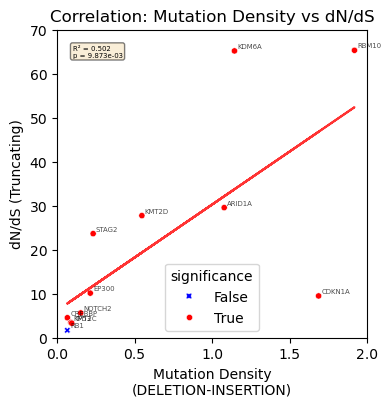

In [26]:
# Call the function with the required dataframes
mutdensity_dnds_scatterplot(mut_den_df, omegas_df, 'Bladder_deepUMIcaller_truncating', 70, 2)

In [27]:
omegas_df[omegas_df['pvalue'] < 0.05].sort_values(by='dnds', ascending=False)

,gene,sample,impact,mutations,dnds,pvalue,lower,upper
424,RBM10,CallerDeepumicaller,truncating,339,65.275391,0.000000,55.645320,76.460083
482,KDM6A,CallerDeepumicaller,truncating,118,65.137500,0.000000,51.872701,81.181812
631,ARID1A,CallerDeepumicaller,truncating,419,29.525098,0.000000,25.032260,34.777783
385,KMT2D,CallerDeepumicaller,truncating,734,27.712109,0.000000,24.161424,31.791699
268,STAG2,CallerDeepumicaller,truncating,50,23.612500,0.000000,17.203349,31.735669
532,EP300,CallerDeepumicaller,truncating,73,10.090625,0.000000,7.532937,13.354785
512,CDKN1A,CallerDeepumicaller,truncating,14,9.451562,0.000000,5.243082,15.642968
642,NOTCH2,CallerDeepumicaller,truncating,46,5.588330,0.000000,3.991506,7.645215
477,CREBBP,CallerDeepumicaller,truncating,33,4.498444,0.000000,3.038275,6.446075
541,KMT2C,CallerDeepumicaller,truncating,19,3.414063,0.000019,2.036980,5.396484


#### DupCaller

In [28]:
omegas_df, mut_den_df = load_omegas_n_mutden(deepcsa_run_dir, gene_order, group = 'CallerDupcaller', consequence = 'truncating')

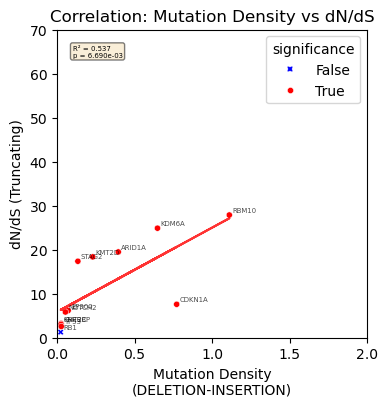

In [29]:
# Call the function with the required dataframes
mutdensity_dnds_scatterplot(mut_den_df, omegas_df, 'Bladder_Dupcaller_truncating', 70, 2)

In [12]:
omegas_df[omegas_df['pvalue'] < 0.05].sort_values(by='dnds', ascending=False)

,gene,sample,impact,mutations,dnds,pvalue,lower,upper
1246,RBM10,CallerDupcaller,truncating,504,27.848438,0.000000e+00,24.196172,32.053149
1340,KDM6A,CallerDupcaller,truncating,196,24.850781,0.000000e+00,20.636612,29.825146
1599,ARID1A,CallerDupcaller,truncating,629,19.450024,0.000000e+00,16.833144,22.460889
1167,KMT2D,CallerDupcaller,truncating,1314,18.325000,0.000000e+00,16.282672,20.651050
963,STAG2,CallerDupcaller,truncating,83,17.334326,0.000000e+00,13.453694,22.065771
1384,CDKN1A,CallerDupcaller,truncating,27,7.553125,0.000000e+00,4.943602,11.068750
1422,EP300,CallerDupcaller,truncating,124,6.132031,0.000000e+00,4.842907,7.712231
1619,NOTCH2,CallerDupcaller,truncating,85,5.799609,0.000000e+00,4.487901,7.413379
1335,CREBBP,CallerDupcaller,truncating,65,3.187109,0.000000e+00,2.380421,4.202124
1441,KMT2C,CallerDupcaller,truncating,33,2.975781,5.960465e-07,2.000462,4.289258


# SigProfilerPlotting

In [33]:
indels_matrix = pd.read_table("samples.ID28.all")
indels_matrix = indels_matrix.set_index('MutationType')
indels_matrix

,P19_0050_BDO_01,P19_0050_BDO_01_dupcaller,P19_0050_BTR_01,P19_0050_BTR_01_dupcaller,P19_0051_BDO_01,P19_0051_BDO_01_dupcaller,P19_0051_BTR_01,P19_0051_BTR_01_dupcaller,P19_0052_BDO_01,P19_0052_BDO_01_dupcaller,P19_0052_BTR_01,P19_0052_BTR_01_dupcaller,P19_0053_BDO_01,P19_0053_BDO_01_dupcaller,P19_0053_BTR_01,P19_0053_BTR_01_dupcaller
MutationType,,,,,,,,,,,,,,,,
1:Del:C:0,28,15,35,19,20,12,29,14,4,3,6,4,13,8,6,4
1:Del:C:1,28,28,46,36,35,16,49,36,10,5,8,7,17,12,23,10
1:Del:C:2,17,18,18,18,24,13,28,20,3,2,4,2,9,6,8,5
1:Del:C:3,11,23,8,13,8,3,6,13,0,0,2,2,2,8,8,10
1:Del:C:4,8,16,7,15,3,9,3,13,2,1,1,1,2,9,2,4
1:Del:C:5,4,10,6,11,5,9,10,11,0,2,1,0,1,4,3,2
1:Del:T:0,14,13,19,12,14,11,22,20,4,5,3,2,16,21,7,7
1:Del:T:1,10,6,13,8,6,3,15,9,1,1,2,3,5,6,4,2
1:Del:T:2,8,6,11,6,7,6,7,9,2,0,1,0,3,3,1,2


In [34]:
indels_matrix.columns

Index(['P19_0050_BDO_01', 'P19_0050_BDO_01_dupcaller', 'P19_0050_BTR_01',
       'P19_0050_BTR_01_dupcaller', 'P19_0051_BDO_01',
       'P19_0051_BDO_01_dupcaller', 'P19_0051_BTR_01',
       'P19_0051_BTR_01_dupcaller', 'P19_0052_BDO_01',
       'P19_0052_BDO_01_dupcaller', 'P19_0052_BTR_01',
       'P19_0052_BTR_01_dupcaller', 'P19_0053_BDO_01',
       'P19_0053_BDO_01_dupcaller', 'P19_0053_BTR_01',
       'P19_0053_BTR_01_dupcaller'],
      dtype='object')

In [36]:
dupcaller_samples = [x for x in indels_matrix.columns if 'dupcaller' in x]
deepUMIcaller_samples = [x for x in indels_matrix.columns if x not in dupcaller_samples]

In [37]:
indels_matrix["DupCaller"] = indels_matrix[dupcaller_samples].sum(axis=1)
indels_matrix["deepUMIcaller"] = indels_matrix[deepUMIcaller_samples].sum(axis=1)

In [39]:
indels_matrix_groups = indels_matrix[["DupCaller", "deepUMIcaller"]].reset_index()

In [40]:
indels_matrix_groups.to_csv("samples.ID28.grouped", sep='\t', index=False)

### Run with sigprofiler_env

In [5]:
import sigProfilerPlotting as sigPlt


sigPlt.plotID("samples.ID28.grouped", "plots/", "ID28_bladder", '28', percentage=False)